In [2]:
from torch_geometric.nn import SAGEConv, global_mean_pool
import torch.nn as nn
import torch.nn.functional as F
import torch
import re
import os 
import tqdm
import networkx as nx
from collections import deque
from torch_geometric.utils import from_networkx
import numpy as np
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import bs4
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils import shuffle
from elasticsearch import Elasticsearch
from dotenv import load_dotenv

import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from data.RawLoader import RawLoader
from data.Elastic import Elastic

# Data Ingestion

In [3]:
load_dotenv()

# get environment variables
host = os.getenv('ELASTICSEARCH_HOST')
user = os.getenv('ELASTICSEARCH_USER')
password = os.getenv('ELASTICSEARCH_PASSWORD')

# establish connection to ELK
connection = Elasticsearch(
    host,
    basic_auth=(user, password),
    timeout=5
)

dataloader = RawLoader()

In [4]:
index_data = dataloader.get_es_index(connection, 'featext2')
index_dict = {hit["_id"]: hit['_source']['type'] for hit in index_data}

In [5]:
miniopath = 'data/capstone'
label_map = {}

for filename in tqdm.tqdm(os.listdir(miniopath)):
    _split = filename.split('_')
    if _split[1] == 'html.html':
        stripped_filename = _split[0]
        label_map[f'data/capstone/{filename}'] = index_dict[stripped_filename]

100%|██████████| 66870/66870 [00:00<00:00, 1014640.84it/s]


In [6]:
"""
zenodopath = 'zenodo'
zenodo_files = []
for directory in os.listdir(zenodopath):
    if directory == '.DS_Store':
        continue
    for file in os.listdir(os.path.join(zenodopath, directory)):
        rpath = os.path.join(zenodopath, directory, file, 'index.html')
        if os.path.exists(rpath):
            zenodo_files.append(rpath) 
"""

"\nzenodopath = 'zenodo'\nzenodo_files = []\nfor directory in os.listdir(zenodopath):\n    if directory == '.DS_Store':\n        continue\n    for file in os.listdir(os.path.join(zenodopath, directory)):\n        rpath = os.path.join(zenodopath, directory, file, 'index.html')\n        if os.path.exists(rpath):\n            zenodo_files.append(rpath) \n"

In [7]:
"""
XTEST = []
yTEST = []

ben, phi = 1000, 1000
for key, val in label_map.items():
    if val == 0 and ben > 0:
        XTEST.append(key)
        yTEST.append(0)
        ben -= 1
    if val == 1 and phi > 0:
        XTEST.append(key)
        yTEST.append(1)
        phi -= 1
"""

'\nXTEST = []\nyTEST = []\n\nben, phi = 1000, 1000\nfor key, val in label_map.items():\n    if val == 0 and ben > 0:\n        XTEST.append(key)\n        yTEST.append(0)\n        ben -= 1\n    if val == 1 and phi > 0:\n        XTEST.append(key)\n        yTEST.append(1)\n        phi -= 1\n'

In [8]:
ben, phi = 1000, 1000
X3 = []
y3 = []

for key, val in label_map.items():
    if val == 0 and ben > 0:
        X3.append(key)
        y3.append(0)
        ben -= 1
    if val == 1 and phi > 0:
        X3.append(key)
        y3.append(1)
        phi -= 1

In [9]:
regex = re.compile(r"\((\d+), '([^']+)', '([^']+)', (\d+), ('[^']+'\))")

mapper = dict()

with open('n96ncsr5g4-1/index.txt', 'r') as file:
    fields = file.readlines()
    for field in fields:
        match = re.match(regex, field)
        if match:
            mapper[match.group(3)] = match.group(4)

print(len(mapper))

79987


In [10]:
# https://data.mendeley.com/datasets/n96ncsr5g4/1

files = []

for part in range(1, 7):  # Dataset parts 1 to 6
    dataset_path = f'n96ncsr5g4-1/dataset/dataset-part-{part}'
    for file in os.listdir(dataset_path):
        full_path = f'{dataset_path}/{file}'
        files.append(full_path)

X1 = []
y1 = []
ben_files_max = 500
phi_files_max = 500

for file in tqdm.tqdm(files):
    # Extract the filename from the full path
    filename = file.split('/')[-1]
    if filename in mapper and mapper[filename] == '1' and phi_files_max > 0:
        X1.append(file)
        y1.append(int(mapper[filename]))
        phi_files_max -= 1
    if filename in mapper and mapper[filename] == '0' and ben_files_max > 0:
        X1.append(file)
        y1.append(int(mapper[filename]))
        ben_files_max -= 1

100%|██████████| 36429/36429 [00:00<00:00, 382906.64it/s]


In [11]:
X2 = []
y2 = []
ben_files_max = 500
phi_files_max = 500

for phase in ['training', 'validation']:
    for label in ['NotPhish', 'Phish']:
        dirpath = os.path.join('archive', phase, label)
        for filename in tqdm.tqdm(os.listdir(dirpath)):
            file = os.path.join(dirpath, filename)
            if label == 'NotPhish' and ben_files_max > 0:
                X2.append(file)
                y2.append(0)
                ben_files_max -= 1
            if label == 'Phish' and phi_files_max > 0:
                X2.append(file)
                y2.append(1)
                phi_files_max -= 1

100%|██████████| 1055/1055 [00:00<00:00, 779184.84it/s]


In [12]:
Xr = X1 + X2 + X3
yr = y1 + y2 + y3

X, y = shuffle(Xr, yr, random_state=42)
# Xts, yts = shuffle(XTEST, yTEST, random_state=42)

In [13]:
# Swap X and Xts
# X, Xts = Xts, X

# Swap y and yts
# y, yts = yts, y

# HTML Graph Construction

In [14]:
# Function to parse HTML and create a DOM tree
def parse_html(html_content):
    """
    Parses the HTML document and returns a DOM tree using BeautifulSoup.
    """
    soup = bs4.BeautifulSoup(html_content, 'html.parser')
    return soup

def build_graph(dom_tree):
    """
    Builds a graph representation of the HTML DOM tree.
    Attributes text only to the most specific node that contains it.
    """
    if dom_tree is None:
        return 0
    
    graph = nx.DiGraph()
    queue = deque([dom_tree])
    
    while queue:
        node = queue.popleft()
        
        if node.name:  # Only consider actual HTML tags
            # Get direct text content (excluding nested tags' text)
            # This gets only the text directly inside this tag, not from children
            direct_text = ''.join(child for child in node.children 
                                if isinstance(child, str)).strip()
            
            # Add node with tag and only its direct text content
            graph.add_node(id(node), 
                         tag=node.name,
                         text=direct_text)
            
            # Add all the children of the current node
            for child in node.children:
                if child.name:  # Only consider valid HTML tags
                    child_direct_text = ''.join(c for c in child.children 
                                              if isinstance(c, str)).strip()
                    graph.add_node(id(child), 
                                 tag=child.name,
                                 text=child_direct_text)
                    graph.add_edge(id(node), id(child))
                    queue.append(child)
    
    return graph

# Function to process all HTML files in X and build graphs
def process_html_files(X):
    graphs = []
    text = []
    
    for file_path in tqdm.tqdm(X):
        # Check if the file exists
        if not os.path.exists(file_path):
            print(f"File {file_path} does not exist.")
            continue
        
        # Read the HTML content from the file
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
            html_content = file.read()
            text.append(html_content)
        
        # Parse the HTML document into a DOM tree
        dom_tree = parse_html(html_content)
        
        # Build the graph from the DOM tree
        graph = build_graph(dom_tree)
        graphs.append(graph)
    
    return graphs, text

# Process all HTML files and build the corresponding graphs
graphs, text = process_html_files(X)

# testgraphs, testtext = process_html_files(Xts)

100%|██████████| 4000/4000 [03:13<00:00, 20.71it/s] 


In [15]:
# HTML tags to one-hot encode
HTML_TAGS = [
    # Basic structure
    'html', 'head', 'body', 'title', 'meta',
    
    # Headers
    'h1', 'h2', 'h3', 'h4', 'h5', 'h6',
    
    # Text content
    'p', 'span', 'div', 'br', 'hr',
    
    # Links and media
    'a', 'img', 'iframe', 'video', 'audio',
    
    # Lists
    'ul', 'ol', 'li', 'dl', 'dt', 'dd',
    
    # Tables
    'table', 'tr', 'td', 'th', 'thead', 'tbody',
    
    # Forms - important for phishing
    'form', 'input', 'button', 'select', 'option', 'textarea', 'label',
    
    # Scripts and styling
    'script', 'style', 'link', 'noscript',
    
    # Semantic elements
    'nav', 'header', 'footer', 'main', 'section', 'article'
]

# Function to one-hot encode the HTML tags
def one_hot_encode_tag(tag, tag_set):
    encoding = np.zeros(len(tag_set))
    if tag in tag_set:
        encoding[tag_set.index(tag)] = 1
    return encoding

# Convert the networkx graph to PyG data format and prepare node features
def convert_to_pyg_graph(graph):
    # Prepare node features (one-hot encoded tags and text presence)
    node_features = []
    for node, data in graph.nodes(data=True):
        tag = data['tag']  # Get the tag
        text = data['text']  # Get the text content
        
        # One-hot encode the tag
        tag_encoding = one_hot_encode_tag(tag, HTML_TAGS)
        
        # Add binary feature for text presence
        has_text = 1.0 if text.strip() else 0.0
        
        # Combine features
        features = np.append(tag_encoding, has_text)
        node_features.append(features)

    # Convert node features to a tensor
    node_features = torch.tensor(node_features, dtype=torch.float32)

    # Convert networkx graph to a PyTorch Geometric graph
    pyg_graph = from_networkx(graph)
    pyg_graph.x = node_features

    return pyg_graph

# Function to process and convert all graphs in the list
def convert_all_graphs_to_pyg(graphs):
    pyg_graphs = []
    for i, graph in tqdm.tqdm(enumerate(graphs)):
        pyg_graph = convert_to_pyg_graph(graph)  # Convert each networkx graph to PyG format
        pyg_graphs.append(pyg_graph)  # Store the converted PyG graph
    
    return pyg_graphs

# Convert all networkx graphs to PyTorch Geometric graphs
pyg_graphs = convert_all_graphs_to_pyg(graphs)

# testpyg_graphs = convert_all_graphs_to_pyg(testgraphs)

0it [00:00, ?it/s]/var/folders/lz/54h48fsx6294gn68v0q9pp4m0000gn/T/ipykernel_73389/2491179711.py:57: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  node_features = torch.tensor(node_features, dtype=torch.float32)
4000it [00:34, 115.54it/s]


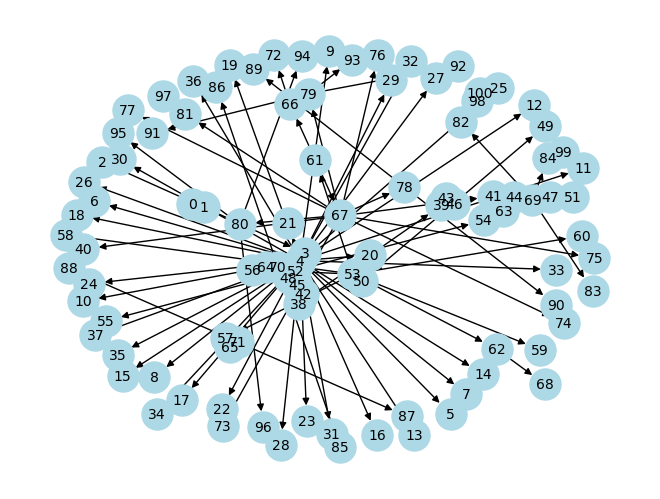

In [16]:
# Convert PyG graph to NetworkX
nx_graph = to_networkx(pyg_graphs[0])

# Visualize the graph
nx.draw(nx_graph, with_labels=True, node_color='lightblue', node_size=500, font_size=10)
plt.show()


In [17]:
def print_pyg_graph_details(pyg_graph, original_graph):
    """
    Print details of a PyTorch Geometric graph including nodes, tags, and text content.
    
    Args:
        pyg_graph: The PyTorch Geometric graph
        original_graph: The original networkx graph that contains text data
    """
    print("PyG Graph Details:")
    print(f"Number of nodes: {pyg_graph.num_nodes}")
    print(f"Number of edges: {pyg_graph.num_edges}")
    print(f"Node feature dimension: {pyg_graph.num_node_features}")
    
    print("\nNode Details:")
    for i in range(pyg_graph.num_nodes):
        # Get one-hot encoded features
        features = pyg_graph.x[i]
        
        # Find the tag from one-hot encoding
        tag_index = torch.argmax(features[:-1]).item()  # Exclude the last feature (has_text)
        tag = HTML_TAGS[tag_index]
        
        # Get original node data from networkx graph
        original_node_data = None
        for node, data in original_graph.nodes(data=True):
            if data['tag'] == tag:
                original_node_data = data
                break
        
        print(f"\nNode {i}:")
        print(f"  Tag: {tag}")
        print(f"  Text content: {original_node_data['text'] if original_node_data['text'] else 'N/A'}")
        print(f"  Has text: {'Yes' if features[-1] == 1 else 'No'}")

print_pyg_graph_details(pyg_graphs[0], graphs[0])

PyG Graph Details:
Number of nodes: 101
Number of edges: 100
Node feature dimension: 51

Node Details:

Node 0:
  Tag: html
  Text content: N/A
  Has text: No

Node 1:
  Tag: html
  Text content: N/A
  Has text: No

Node 2:
  Tag: head
  Text content: N/A
  Has text: No

Node 3:
  Tag: body
  Text content: N/A
  Has text: No

Node 4:
  Tag: html
  Text content: N/A
  Has text: Yes

Node 5:
  Tag: meta
  Text content: N/A
  Has text: No

Node 6:
  Tag: script
  Text content: N/A
  Has text: No

Node 7:
  Tag: meta
  Text content: N/A
  Has text: No

Node 8:
  Tag: meta
  Text content: N/A
  Has text: No

Node 9:
  Tag: title
  Text content: Verify Email
  Has text: Yes

Node 10:
  Tag: style
  Text content: body{-webkit-font-smoothing:antialiased;-moz-osx-font-smoothing:grayscale}
.ux-content-box *,.ux-content-box :after,.ux-content-box :before{-webkit-box-sizing:content-box;-moz-box-sizing:content-box;box-sizing:content-box}
.pc-sprite{background-color:transparent;background-repeat:no-

# HTML Content DataLoader

In [18]:
from collections import Counter

def normalize_token(token):
    """
    Normalize tokens by lowercasing and stripping excessive whitespace.
    """
    return token.lower().strip()

def build_vocabulary(html_strings, min_freq=5, max_vocab_size=30000):
    """
    Build token-level vocabulary from HTML strings with improvements.
    """
    token_freq = Counter()

    # Count token frequencies
    for html in tqdm.tqdm(html_strings, desc="Building Vocabulary"):
        soup = bs4.BeautifulSoup(html, 'html.parser')
        
        for element in soup.descendants:
            if element.name:
                # Normalize HTML tag
                token = normalize_token(f"<{element.name}>")
                token_freq[token] += 1
                
                # Normalize and add attributes
                for attr in ['href', 'src', 'class', 'id']:
                    if attr in element.attrs:
                        # Limit overly unique tokens (e.g., specific IDs)
                        value = str(element.attrs[attr])[:30]  # Cap length of attribute values
                        token = normalize_token(f"{attr}={value}")
                        token_freq[token] += 1
            
            elif isinstance(element, bs4.NavigableString):
                text = normalize_token(str(element))
                if text:
                    words = text.split()
                    token_freq.update(words)

    # Create vocabulary, limiting size and applying frequency threshold
    vocab = {'<pad>': 0, '<unk>': 1}
    idx = len(vocab)
    
    for token, freq in token_freq.most_common(max_vocab_size - len(vocab)):
        if freq >= min_freq:
            vocab[token] = idx
            idx += 1

    return vocab

# Encode HTML to token index sequences
def encode_html(html_string, token_to_idx, max_tokens=100):
    """
    Convert HTML string to token index sequence with normalization.
    """
    tokens = []
    soup = bs4.BeautifulSoup(html_string, 'html.parser')

    for element in soup.descendants:
        if element.name:
            tokens.append(normalize_token(f"<{element.name}>"))
            for attr in ['href', 'src', 'class', 'id']:
                if attr in element.attrs:
                    value = str(element.attrs[attr])[:30]  # Cap length of attribute values
                    tokens.append(normalize_token(f"{attr}={value}"))
        elif isinstance(element, bs4.NavigableString):
            text = normalize_token(str(element))
            if text:
                tokens.extend(text.split())

    # Convert tokens to indices
    indices = [token_to_idx.get(token, token_to_idx['<unk>']) for token in tokens[:max_tokens]]

    # Pad to max_tokens
    if len(indices) < max_tokens:
        indices += [token_to_idx['<pad>']] * (max_tokens - len(indices))

    return torch.tensor(indices, dtype=torch.long)

# Build vocabulary
token_to_idx = build_vocabulary(text, min_freq=5, max_vocab_size=30000)
print(f"Vocabulary size: {len(token_to_idx)}")

# Process training data
X_cnn = []
for html in tqdm.tqdm(text, desc="Encoding Training Data"):
    encoded = encode_html(html, token_to_idx)
    X_cnn.append(encoded)

X_cnn = torch.stack(X_cnn)
print(f"CNN input shape: {X_cnn.shape}")

# Encode test data
# Xts_cnn = []
# for html in tqdm.tqdm(Xts, desc="Encoding Test Data"):
#     encoded = encode_html(html, token_to_idx)
#     Xts_cnn.append(encoded)

# # Stack into a tensor
# Xts_cnn = torch.stack(Xts_cnn)
# print(f"Test CNN input shape: {Xts_cnn.shape}")


Building Vocabulary: 100%|██████████| 4000/4000 [03:14<00:00, 20.61it/s] 


Vocabulary size: 30000


Encoding Training Data: 100%|██████████| 4000/4000 [03:08<00:00, 21.26it/s] 

CNN input shape: torch.Size([4000, 100])


# Hybrid Dataset Creation

In [19]:
class HybridDataset(Dataset):
    def __init__(self, pyg_graphs, cnn_features, labels):
        self.pyg_graphs = pyg_graphs
        self.cnn_features = cnn_features
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.pyg_graphs[idx], self.cnn_features[idx], self.labels[idx]

def collate_hybrid_batch(batch):
    """Custom collate function to handle both PyG graphs and CNN features"""
    graphs, cnn_features, labels = zip(*batch)
    
    # Collate graphs using PyG's Batch
    batched_graphs = Batch.from_data_list(list(graphs))
    
    # Stack CNN features and labels
    batched_cnn = torch.stack(cnn_features)
    batched_labels = torch.tensor(labels)
    
    return batched_graphs, batched_cnn, batched_labels

# Create train/val/test splits
train_size = int(0.7 * len(pyg_graphs))
val_size = int(0.15 * len(pyg_graphs))
indices = torch.randperm(len(pyg_graphs))

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

labels = y

# Create DataLoaders
train_loader = DataLoader(
    HybridDataset([pyg_graphs[i] for i in train_idx], X_cnn[train_idx], [labels[i] for i in train_idx]),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_hybrid_batch
)

val_loader = DataLoader(
    HybridDataset([pyg_graphs[i] for i in val_idx], X_cnn[val_idx], [labels[i] for i in val_idx]),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_hybrid_batch
)

test_loader = DataLoader(
    HybridDataset([pyg_graphs[i] for i in test_idx], X_cnn[test_idx], [labels[i] for i in test_idx]),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_hybrid_batch
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 88
Number of validation batches: 19
Number of test batches: 19


# Model Training

In [20]:
class HybridPhishDetector(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, dropout=0.5):
        super(HybridPhishDetector, self).__init__()
        
        # CNN Component
        self.embedding = nn.Embedding(in_feats, 32)  # Add embedding layer
        self.cnn = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),  # Add dropout
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),  # Add dropout
            
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(0.3)  # Add dropout
        )
        
        # Graph Component
        self.sage1 = SAGEConv((-1, -1), hidden_feats)
        self.sage2 = SAGEConv((-1, -1), hidden_feats)
        self.sage3 = SAGEConv((-1, -1), hidden_feats)
        
        # Fusion and Classification
        self.fusion = nn.Sequential(
            nn.Linear(256 + hidden_feats, hidden_feats // 2),  # Reduce hidden size
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats // 2, out_feats)
        )
        
    def forward(self, graph_data, x_seq):
        # Process sequential features through CNN
        x_emb = self.embedding(x_seq)  # (batch_size, seq_len, emb_dim)
        x_emb = x_emb.transpose(1, 2)  # (batch_size, emb_dim, seq_len)
        cnn_features = self.cnn(x_emb)  # (batch_size, 256, 1)
        cnn_features = cnn_features.squeeze(-1)  # (batch_size, 256)
        
        # Process graph features through GraphSAGE
        x, edge_index, batch = graph_data.x, graph_data.edge_index, graph_data.batch
        x = F.relu(self.sage1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)  # Add dropout
        x = F.relu(self.sage2(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)  # Add dropout
        x = self.sage3(x, edge_index)
        graph_features = global_mean_pool(x, batch)  # (batch_size, hidden_feats)
        
        # Combine features and classify
        combined = torch.cat([cnn_features, graph_features], dim=1)
        out = self.fusion(combined)
        
        return out

In [21]:
# Debug the token indices
print("Vocabulary size:", len(token_to_idx))
print("Max token index in data:", X_cnn.max().item())
print("Min token index in data:", X_cnn.min().item())
print("CNN input shape:", X_cnn.shape)

# If the max index is >= vocab size, we need to fix our encoding
if X_cnn.max() >= len(token_to_idx):
    raise ValueError(f"Token indices {X_cnn.max()} exceed vocabulary size {len(token_to_idx)}")

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []
    
    for graphs, cnn_features, labels in train_loader:
        # Move data to device
        graphs = graphs.to(device)
        cnn_features = cnn_features.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(graphs, cnn_features)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Store predictions
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='binary')
    
    return total_loss / len(train_loader), accuracy, precision, recall, f1

def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for graphs, cnn_features, labels in data_loader:
            # Move data to device
            graphs = graphs.to(device)
            cnn_features = cnn_features.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(graphs, cnn_features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            # Store predictions
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='binary')
    
    return total_loss / len(data_loader), accuracy, precision, recall, f1

# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size = len(token_to_idx)
model = HybridPhishDetector(
    in_feats=vocab_size,  # Change this from X_cnn.shape[1] to vocab_size
    hidden_feats=128,
    out_feats=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
n_epochs = 20

# Training loop
best_val_f1 = 0
for epoch in range(n_epochs):
    # Train
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(
        model, val_loader, criterion, device
    )
    
    # Print metrics
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
    print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_hybrid_model.pt')

# Final evaluation on test set
model.load_state_dict(torch.load('best_hybrid_model.pt'))
test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(
    model, test_loader, criterion, device
)
print("\nTest Set Performance:")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall: {test_rec:.4f}")
print(f"F1-Score: {test_f1:.4f}")

Vocabulary size: 30000
Max token index in data: 29690
Min token index in data: 0
CNN input shape: torch.Size([4000, 100])
Epoch 1/20
Train - Loss: 0.6652, Acc: 0.5879, F1: 0.6742
Val   - Loss: 0.6278, Acc: 0.6583, F1: 0.7016
Epoch 2/20
Train - Loss: 0.6287, Acc: 0.6450, F1: 0.6702
Val   - Loss: 0.6039, Acc: 0.6967, F1: 0.7407
Epoch 3/20
Train - Loss: 0.5777, Acc: 0.7018, F1: 0.7143
Val   - Loss: 0.5653, Acc: 0.7333, F1: 0.7203
Epoch 4/20
Train - Loss: 0.5388, Acc: 0.7375, F1: 0.7415
Val   - Loss: 0.5382, Acc: 0.7533, F1: 0.7695
Epoch 5/20
Train - Loss: 0.5019, Acc: 0.7621, F1: 0.7657
Val   - Loss: 0.5142, Acc: 0.7750, F1: 0.7819
Epoch 6/20
Train - Loss: 0.4538, Acc: 0.7925, F1: 0.7938
Val   - Loss: 0.5060, Acc: 0.7550, F1: 0.7685
Epoch 7/20
Train - Loss: 0.3981, Acc: 0.8221, F1: 0.8237
Val   - Loss: 0.5669, Acc: 0.7367, F1: 0.7276
Epoch 8/20
Train - Loss: 0.3584, Acc: 0.8407, F1: 0.8430
Val   - Loss: 0.5086, Acc: 0.7600, F1: 0.7714
Epoch 9/20
Train - Loss: 0.3303, Acc: 0.8507, F1: 0.85

/var/folders/lz/54h48fsx6294gn68v0q9pp4m0000gn/T/ipykernel_73389/3958498496.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_hybr


Test Set Performance:
Accuracy: 0.7550
Precision: 0.7130
Recall: 0.8105
F1-Score: 0.7586
